In [1]:
from astropy.table import Table, vstack
from astroquery.gaia import Gaia
from matplotlib import pyplot as plt
import numpy as np
import os
import pandas as pd
import pathlib

In [2]:
os.chdir(pathlib.Path.cwd())
def set_rcparams():
    tab = Table.read('rcparams.txt', format='csv')
    for i in range(len(tab)):
        try:
            plt.rcParams[tab['key'][i]] = float(tab['val'][i])
        except ValueError:
            plt.rcParams[tab['key'][i]] = str(tab['val'][i])
    return
set_rcparams()

In [ ]:
reportable = pd.read_csv('(#path to#)reportable.csv', index_col='Unnamed: 0')
reportable['bp-rp'] = reportable['phot_bp_mean_mag']-reportable['phot_rp_mean_mag']
reportable['abs_g_mag'] = reportable['phot_g_mean_mag'] - 5*np.log10(1000/reportable['parallax']) + 5
reportable['frac'] = reportable['sigma']/reportable['period']

/Users/mschochet/anaconda3/envs/asassncnn/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [4]:
cold = reportable[reportable['bp-rp'] >= 0.6]

nonoscillators = cold[cold['abs_g_mag'] > (2*cold['bp-rp'] - 4)]

subgiants = nonoscillators[nonoscillators['abs_g_mag'] < (1.4*nonoscillators['bp-rp']+2.8)]
ms = nonoscillators[nonoscillators['abs_g_mag'] >= (1.4*nonoscillators['bp-rp']+2.8)]

In [ ]:
dr3_ids_ms = ms['dr3_source_id'].to_list()
dr3_ids_sg = subgiants['dr3_source_id'].to_list()
query_sg = f"SELECT gsource.source_id AS dr3_source_id, gsource.mass_flame, gsource.mass_flame_lower, gsource.mass_flame_upper FROM gaiadr3.astrophysical_parameters AS gsource WHERE gsource.source_id IN ({','.join(map(str, dr3_ids_sg))}) "
query_ms = f"SELECT gsource.source_id AS dr3_source_id, gsource.mass_flame, gsource.mass_flame_lower, gsource.mass_flame_upper FROM gaiadr3.astrophysical_parameters AS gsource WHERE gsource.source_id IN ({','.join(map(str, dr3_ids_ms))}) "

In [6]:
job1 = Gaia.launch_job(query_sg)
job2 = Gaia.launch_job(query_ms)

result_table_sg = job1.get_results().to_pandas().drop_duplicates(subset='dr3_source_id').drop(axis=1, columns='dr3_id_2')
result_table_ms = job2.get_results().to_pandas().drop_duplicates(subset='dr3_source_id').drop(axis=1, columns='dr3_id_2')

In [7]:
merged_sg = pd.merge(nonoscillators, result_table_sg, on='dr3_source_id', how='inner')
merged_ms = pd.merge(nonoscillators, result_table_ms, on='dr3_source_id', how='inner')

hasmass_sg = merged_sg.dropna(axis='rows', subset='mass_flame', how='any')
hasmass_ms = merged_ms.dropna(axis='rows', subset='mass_flame', how='any')

In [143]:
len(hasmass_ms)

1470

In [8]:
hasmass_sg['tau_conv'] = 10**(1.16 - (1.49*np.log10(hasmass_sg['mass_flame'])) - (0.54 * (np.log10(hasmass_sg['mass_flame']))**2))
hasmass_sg['rossby'] = hasmass_sg['period']/hasmass_sg['tau_conv']

hasmass_ms['tau_conv'] = 10**(1.16 - (1.49*np.log10(hasmass_ms['mass_flame'])) - (0.54 * (np.log10(hasmass_ms['mass_flame']))**2))
hasmass_ms['rossby'] = hasmass_ms['period']/hasmass_ms['tau_conv']

/var/folders/s0/h_46lpt56ll2ptpy3684xkym0000gn/T/ipykernel_78542/4074451150.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hasmass_sg['tau_conv'] = 10**(1.16 - (1.49*np.log10(hasmass_sg['mass_flame'])) - (0.54 * (np.log10(hasmass_sg['mass_flame']))**2))
/var/folders/s0/h_46lpt56ll2ptpy3684xkym0000gn/T/ipykernel_78542/4074451150.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hasmass_sg['rossby'] = hasmass_sg['period']/hasmass_sg['tau_conv']
/var/folders/s0/h_46lpt56ll2ptpy3684xkym0000gn/T/ipykernel

In [9]:
solar_prot_min = 25.67
solar_prot_max = 33.60
solar_tauconv = 10**1.16
solar_rossby_mi = solar_prot_min/solar_tauconv
solar_rossby_ma = solar_prot_max/solar_tauconv

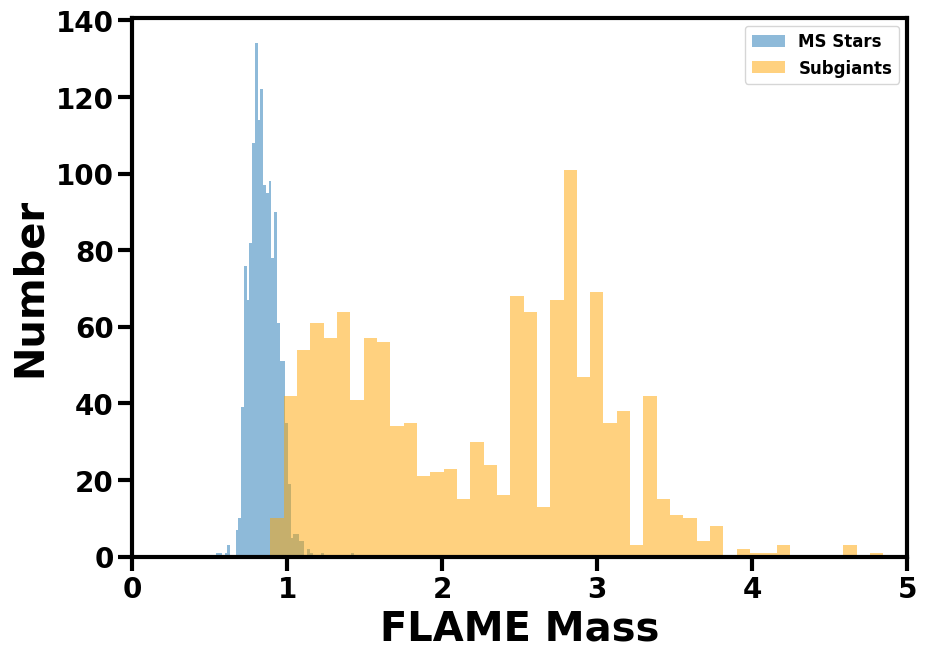

In [12]:
fig, ax = plt.subplots(1, figsize=(10, 7))
h = ax.hist(hasmass_ms['mass_flame'], bins=50, alpha=0.5, label='MS Stars')
h2 = ax.hist(hasmass_sg['mass_flame'], bins=50, color='orange', alpha=0.5, label="Subgiants")
ax.set(xlabel='FLAME Mass', ylabel='Number', xlim=(0, 5))
ax.legend(fontsize=12)

# there appears to be a bimodality in the subgiants, lets cut them by mass

In [14]:
lowmass = hasmass_sg[hasmass_sg['mass_flame'] < 2.1] #579 total
bigmass = hasmass_sg[hasmass_sg['mass_flame'] >= 2.1] #690 total
hasmass_ms #1470 total

,asas_sn_id,period,sigma,dr3_source_id,dr2_source_id,edr3_source_id,KIC,tic_id,ra_rad,dec_rad,...,mass_flame_upper,age_flame,age_flame_lower,age_flame_upper,vrplane_med,vz_med,vphi_med,energy_med,tau_conv,rossby
0,231929290689,9.511509,1.983575,618111219131658240,618111219131658240,618111219131658240,NaN,263542848.0,2.528700,0.270472,...,0.762398,0.262604,0.200000,2.916905,-27.556608,0.467734,253.924637,-159263.828125,22.891228,0.415509
1,377957516391,25.628582,6.260658,76300510625993344,76300510625993344,76300510625993344,NaN,408628165.0,0.625380,0.269119,...,1.008378,5.834100,4.729175,6.938673,47.512547,36.116577,274.674896,-152476.765625,15.159876,1.690554
2,317828523563,14.764905,3.136345,54204072119374336,54204072119374336,54204072119374336,NaN,303503431.0,0.893835,0.268248,...,0.867571,13.269313,9.904073,13.500000,25.249229,-8.291451,232.611740,-163750.750000,19.122375,0.772127
3,309238872575,12.128543,1.810240,1774513537034660864,1774513532739361536,1774513537034660864,NaN,60655696.0,-0.498768,0.264687,...,0.714966,12.476359,9.224331,13.500000,2.748861,2.750596,224.875381,-167123.593750,25.039856,0.484370
4,317827993114,13.915276,1.779435,652802009284056960,652802009284056960,652802009284056960,NaN,6952965.0,2.199794,0.276894,...,0.975015,1.663858,0.200000,3.304227,13.056410,-11.225898,244.221695,-161210.578125,15.999523,0.869731
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1993,154619653005,18.490545,4.605661,1443850120947938304,1443850120947938304,1443850120947938304,NaN,328934382.0,-2.702587,0.412959,...,0.828106,NaN,NaN,NaN,18.898439,-11.391420,233.944931,-164749.109375,20.338263,0.909151
1994,154620166511,10.799502,1.946848,1206919864973428608,1206919864973428608,1206919864973428608,NaN,236323100.0,-2.071214,0.419868,...,0.917789,NaN,NaN,NaN,-71.211609,-10.868101,217.721161,-166722.531250,17.494448,0.617310
1996,197569157414,18.670134,3.845647,1731084305206230016,1731084305206230016,1731084305206230016,NaN,396637716.0,-0.783937,0.045726,...,0.873101,10.102345,8.061568,12.506661,11.641642,16.030123,236.582596,-164959.078125,18.853834,0.990257
1997,266288603119,16.002007,2.467047,1730409887965394304,1730409887965394304,1730409887965394304,NaN,408334522.0,-0.753526,0.050628,...,0.791273,11.434108,9.036302,13.500000,-12.565148,0.259862,246.341797,-162115.671875,21.715124,0.736906


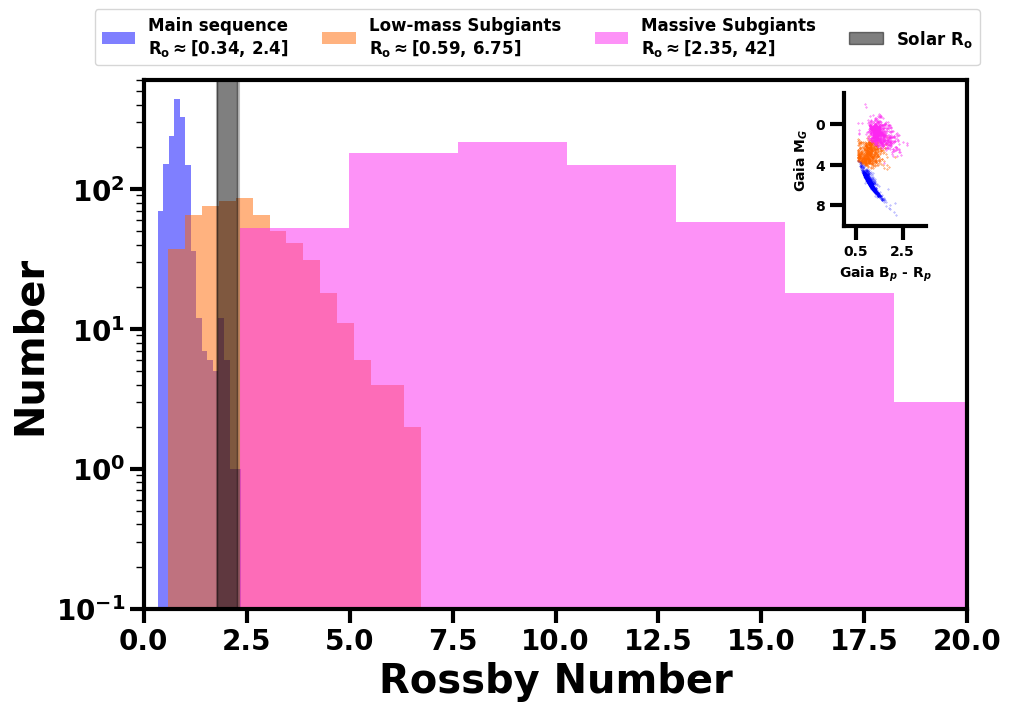

In [151]:
fig, ax = plt.subplots(1, figsize=(10, 7), layout='constrained')


h = ax.hist(hasmass_ms['rossby'], bins=15, color='blue', label="Main sequence\n" +  r'R$_{\rm{o}}$$\approx$[0.34, 2.4]', alpha=0.5, rasterized=True)
h2 = ax.hist(lowmass['rossby'], bins=15, color='#FF6600', label="Low-mass Subgiants\n"+r'R$_{\rm{o}}$$\approx$[0.59, 6.75]', alpha=0.5, rasterized=True)
h3 = ax.hist(bigmass['rossby'], bins=15, color="#FC27F1", label="Massive Subgiants\n"+r'R$_{\rm{o}}$$\approx$[2.35, 42]', alpha=0.5, rasterized=True)
solar_ro_min = ax.vlines(solar_rossby_mi, ymin=0, ymax=600, color='black', alpha=0.25, rasterized=True)
solar_ro_max = ax.vlines(solar_rossby_ma, ymin=0, ymax=600, color='black', alpha=0.25, rasterized=True)
x=np.arange(solar_rossby_mi, solar_rossby_ma, 0.1)
ax.fill_between(x, 0, 600, alpha=0.5, color='k', label=r'Solar R$_{\rm{o}}$', rasterized=True)
ax.set_yscale('log')
ax.set(xlabel='Rossby Number', ylabel='Number', xlim=(0, 20), ylim=(0.1, 600))
ax.legend(ncols=4, fontsize=12, bbox_to_anchor=(0.025, 1.1, 1.0, 0.05))
axin1 = ax.inset_axes([0.85, 0.725, 0.1, 0.25])

axin1.set(xlim=(0, 3.5), ylim=(10, -3), xlabel='Gaia B$_\rm{p}$ - R$_p$', ylabel='Gaia M$_G$')
im1 = axin1.scatter('bp-rp', 'abs_g_mag', data=lowmass, s=.1, c ="#FF6600", rasterized=True)
im1 = axin1.scatter('bp-rp', 'abs_g_mag', data=bigmass,  s=.1, c="#FC27F1", rasterized=True)
im1 = axin1.scatter('bp-rp', 'abs_g_mag', data=hasmass_ms, s=.1, c='blue', alpha=0.5, rasterized=True)
axin1.set_xlabel('Gaia B$_p$ - R$_p$', fontsize=10)
axin1.set_ylabel(f'Gaia M$_G$', fontsize=10)
axin1.set_xticks(ticks=(0.5, 2.5), labels=[0.5, 2.5], fontsize=10)
axin1.set_yticks(ticks=[0, 4, 8], labels=[0, 4, 8], fontsize=10)
axin1.set(facecolor=(0.0, 0.0, 0.0, 0.0))
axin1.spines['top'].set_visible(False)
axin1.spines['right'].set_visible(False)
axin1.tick_params(right=False, top=False, labelright=False, labeltop=False)

fig.savefig('rossby_num.pdf', dpi=300)